# **TUGAS BESAR MACHINE LEARNING - CLUSTERING**

 📌 **TUJUAN CLUSTER:**
 1. Mengelompokkan 38 provinsi di Indonesia ke dalam cluster
 2. berdasarkan indikator kualitas hidup (pendidikan, kesehatan,
 sanitasi, dan akses internet) untuk mengevaluasi kesiapan
 masing-masing provinsi menuju Visi Indonesia Emas 2045.

 Hasil pengelompokan ini diharapkan dapat menjadi dasar
 rekomendasi kebijakan yang lebih tepat sasaran dalam
 upaya pemerataan pembangunan dan peningkatan kualitas
 sumber daya manusia antar daerah.

📊 **VARIABEL DAN SATUAN:**

1. Pengeluaran per kapita → Rupiah (Rp) - Indikator Kesejahteraan Materi
2. Tamat SMA/SMK    → Persen (%) - Indikator Pendidikan
3. BPJS Kesehatan    → Persen (%) - Indikator Kesehatan
4. Toilet pribadi    → Persen (%) - Indikator Sanitasi
5. Pakai Internet    → Persen (%) - Indikator Akses Digital
6. Rumah Pribadi → Persen (%) - Indikator Kepemilikan Aset


**Metode Utama:** HIERARCHICAL CLUSTERING (Ward's linkage)

**Baseline:** K-MEANS CLUSTERING

**Data:** BPS 2024 - 38 Provinsi

In [ ]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("CLUSTERING PROVINSI INDONESIA BERDASARKAN INDIKATOR KUALITAS HIDUP")
print("EVALUASI KESIAPAN MENUJU INDONESIA EMAS 2045")
print("="*70)

# Cetak Tujuan Cluster
print("\n" + "="*70)
print("📌 TUJUAN CLUSTER:")
print("="*70)
print("Mengelompokkan 38 provinsi di Indonesia ke dalam cluster")
print("berdasarkan indikator kualitas hidup (ekonomi, pendidikan, kesehatan,")
print("sanitasi, akses digital, dan kepemilikan aset) untuk mengevaluasi kesiapan")
print("masing-masing provinsi menuju Visi Indonesia Emas 2045.")
print("="*70)

# Cetak Variabel dan Satuan (6 variabel, bukan 4)
print("\n📊 VARIABEL DAN SATUAN:")
print("="*70)
print("1. Pengeluaran per Kapita → Rupiah (Rp) - Indikator Ekonomi")
print("2. Tamat SMA/SMK         → Persen (%) - Indikator Pendidikan")
print("3. BPJS Kesehatan        → Persen (%) - Indikator Kesehatan")
print("4. Toilet pribadi        → Persen (%) - Indikator Sanitasi")
print("5. Akses Internet        → Persen (%) - Indikator Akses Digital")
print("6. Rumah Pribadi         → Persen (%) - Indikator Kepemilikan Aset")

CLUSTERING PROVINSI INDONESIA BERDASARKAN INDIKATOR KUALITAS HIDUP
EVALUASI KESIAPAN MENUJU INDONESIA EMAS 2045

📌 TUJUAN CLUSTER:
Mengelompokkan 38 provinsi di Indonesia ke dalam cluster
berdasarkan indikator kualitas hidup (ekonomi, pendidikan, kesehatan,
sanitasi, akses digital, dan kepemilikan aset) untuk mengevaluasi kesiapan
masing-masing provinsi menuju Visi Indonesia Emas 2045.

📊 VARIABEL DAN SATUAN:
1. Pengeluaran per Kapita → Rupiah (Rp) - Indikator Ekonomi
2. Tamat SMA/SMK         → Persen (%) - Indikator Pendidikan
3. BPJS Kesehatan        → Persen (%) - Indikator Kesehatan
4. Toilet pribadi        → Persen (%) - Indikator Sanitasi
5. Akses Internet        → Persen (%) - Indikator Akses Digital
6. Rumah Pribadi         → Persen (%) - Indikator Kepemilikan Aset


In [ ]:
# Upload File
print("\n📁 STEP 1: UPLOAD FILE DATASET PROVINSI 2024")
print("-"*50)
print("Silakan upload file Excel yang berisi data provinsi")
print("(Kolom: Provinsi, Pengeluaran per Kapita, Tamat SMA/SMK, BPJS Kesehatan,")
print("        Toilet pribadi, Akses Internet, Rumah Pribadi)")

uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"\n✅ File {filename} berhasil diupload!")


📁 STEP 1: UPLOAD FILE DATASET PROVINSI 2024
--------------------------------------------------
Silakan upload file Excel yang berisi data provinsi
(Kolom: Provinsi, Pengeluaran per Kapita, Tamat SMA/SMK, BPJS Kesehatan,
        Toilet pribadi, Akses Internet, Rumah Pribadi)


Saving Dataset_2024.xlsx to Dataset_2024.xlsx

✅ File Dataset_2024.xlsx berhasil diupload!


In [ ]:
# Read Data
print("\n📊 STEP 2: MEMBACA DATA")
print("-"*50)

df = pd.read_excel(filename)

print(f"Jumlah provinsi: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print("\n5 data pertama:")
print(df.head())
print("\nNama kolom:")
print(df.columns.tolist())


📊 STEP 2: MEMBACA DATA
--------------------------------------------------
Jumlah provinsi: 38
Jumlah kolom: 7

5 data pertama:
         Provinsi  Pengeluaran per Kapita  Tamat SMA/SMK  BPJS Kesehatan  \
0            Aceh                 1264733          34.46           97.00   
1  Sumatera Utara                 1340957          41.29           64.30   
2  Sumatera Barat                 1480853          34.41           71.21   
3            Riau                 1563165          34.05           65.24   
4           Jambi                 1472501          30.08           57.66   

   Toilet pribadi  Akses Internet  Rumah Pribadi  
0           86.39           62.93          85.14  
1           91.30           74.15          72.93  
2           83.50           74.59          72.63  
3           95.70           77.68          78.46  
4           90.78           71.76          89.27  

Nama kolom:
['Provinsi', 'Pengeluaran per Kapita', 'Tamat SMA/SMK', 'BPJS Kesehatan', 'Toilet pribadi', 'Aks

In [ ]:
# Preprocessing
print("\n🔧 STEP 3: PREPROCESSING")
print("-"*50)

# Set provinsi sebagai index
df.set_index('Provinsi', inplace=True)

# Pilih variabel untuk clustering (6 variabel)
kolom_clustering = [
    'Pengeluaran per Kapita',
    'Tamat SMA/SMK',
    'BPJS Kesehatan',
    'Toilet pribadi',
    'Akses Internet',
    'Rumah Pribadi'
]

satuan = ['Rp', '%', '%', '%', '%', '%']
nama_variabel = [
    'Pengeluaran per Kapita',
    'Pendidikan (Tamat SMA/SMK)',
    'Kesehatan (BPJS)',
    'Sanitasi (Toilet pribadi)',
    'Digital (Akses Internet)',
    'Kepemilikan Rumah'
]

# Pastikan kolom yang dipilih ada di dataframe
kolom_tersedia = [kol for kol in kolom_clustering if kol in df.columns]
if len(kolom_tersedia) < 6:
    print(f"⚠️ Peringatan: Kolom yang tersedia hanya {kolom_tersedia}")
    kolom_clustering = kolom_tersedia

data_cluster = df[kolom_clustering].copy()

print(f"\nVariabel yang digunakan untuk clustering (dengan satuan):")
for i, var in enumerate(kolom_clustering):
    print(f"   {i+1}. {var} ({satuan[i]})")

print(f"\nShape data: {data_cluster.shape}")

# Cek missing value
print(f"\nMissing value per kolom:")
print(data_cluster.isnull().sum())

# Cek statistik deskriptif
print("\n📊 STATISTIK DESKRIPTIF DATA (DENGAN SATUAN):")
print("="*70)
for i, var in enumerate(kolom_clustering):
    print(f"{var:<30} | Satuan: {satuan[i]:<5} | Rata-rata: {data_cluster[var].mean():>12,.0f} | Min: {data_cluster[var].min():>12,.0f} | Max: {data_cluster[var].max():>12,.0f}")
print("="*70)

# Deteksi outlier dengan metode IQR
print("\n📊 INFORMASI OUTLIER (Metode IQR):")
print("-"*50)
for i, var in enumerate(kolom_clustering):
    Q1 = data_cluster[var].quantile(0.25)
    Q3 = data_cluster[var].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data_cluster[(data_cluster[var] < Q1 - 1.5*IQR) | (data_cluster[var] > Q3 + 1.5*IQR)]
    print(f"   {var}: {len(outliers)} outlier")

# Cetak daftar provinsi outlier
print("\n📋 DAFTAR PROVINSI OUTLIER PER VARIABEL:")
print("-"*50)
for i, var in enumerate(kolom_clustering):
    Q1 = data_cluster[var].quantile(0.25)
    Q3 = data_cluster[var].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data_cluster[(data_cluster[var] < Q1 - 1.5*IQR) | (data_cluster[var] > Q3 + 1.5*IQR)]
    if len(outliers) > 0:
        print(f"\n   {var}:")
        for idx in outliers.index:
            print(f"      - {idx}: {data_cluster.loc[idx, var]:,.0f} {satuan[i]}")

# Normalisasi data dengan MinMaxScaler (lebih robust terhadap outlier)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_cluster)

print("\n✅ Preprocessing selesai!")
print(f"Data siap clustering: {data_scaled.shape[0]} provinsi × {data_scaled.shape[1]} variabel")


🔧 STEP 3: PREPROCESSING
--------------------------------------------------

Variabel yang digunakan untuk clustering (dengan satuan):
   1. Pengeluaran per Kapita (Rp)
   2. Tamat SMA/SMK (%)
   3. BPJS Kesehatan (%)
   4. Toilet pribadi (%)
   5. Akses Internet (%)
   6. Rumah Pribadi (%)

Shape data: (38, 6)

Missing value per kolom:
Pengeluaran per Kapita    0
Tamat SMA/SMK             0
BPJS Kesehatan            0
Toilet pribadi            0
Akses Internet            0
Rumah Pribadi             0
dtype: int64

📊 STATISTIK DESKRIPTIF DATA (DENGAN SATUAN):
Pengeluaran per Kapita         | Satuan: Rp    | Rata-rata:    1,515,437 | Min:      975,854 | Max:    2,794,485
Tamat SMA/SMK                  | Satuan: %     | Rata-rata:           31 | Min:           16 | Max:           49
BPJS Kesehatan                 | Satuan: %     | Rata-rata:           70 | Min:           26 | Max:           97
Toilet pribadi                 | Satuan: %     | Rata-rata:           86 | Min:           44 | 


🔵 STEP 4: METODE UTAMA - HIERARCHICAL CLUSTERING (Ward's linkage)
--------------------------------------------------


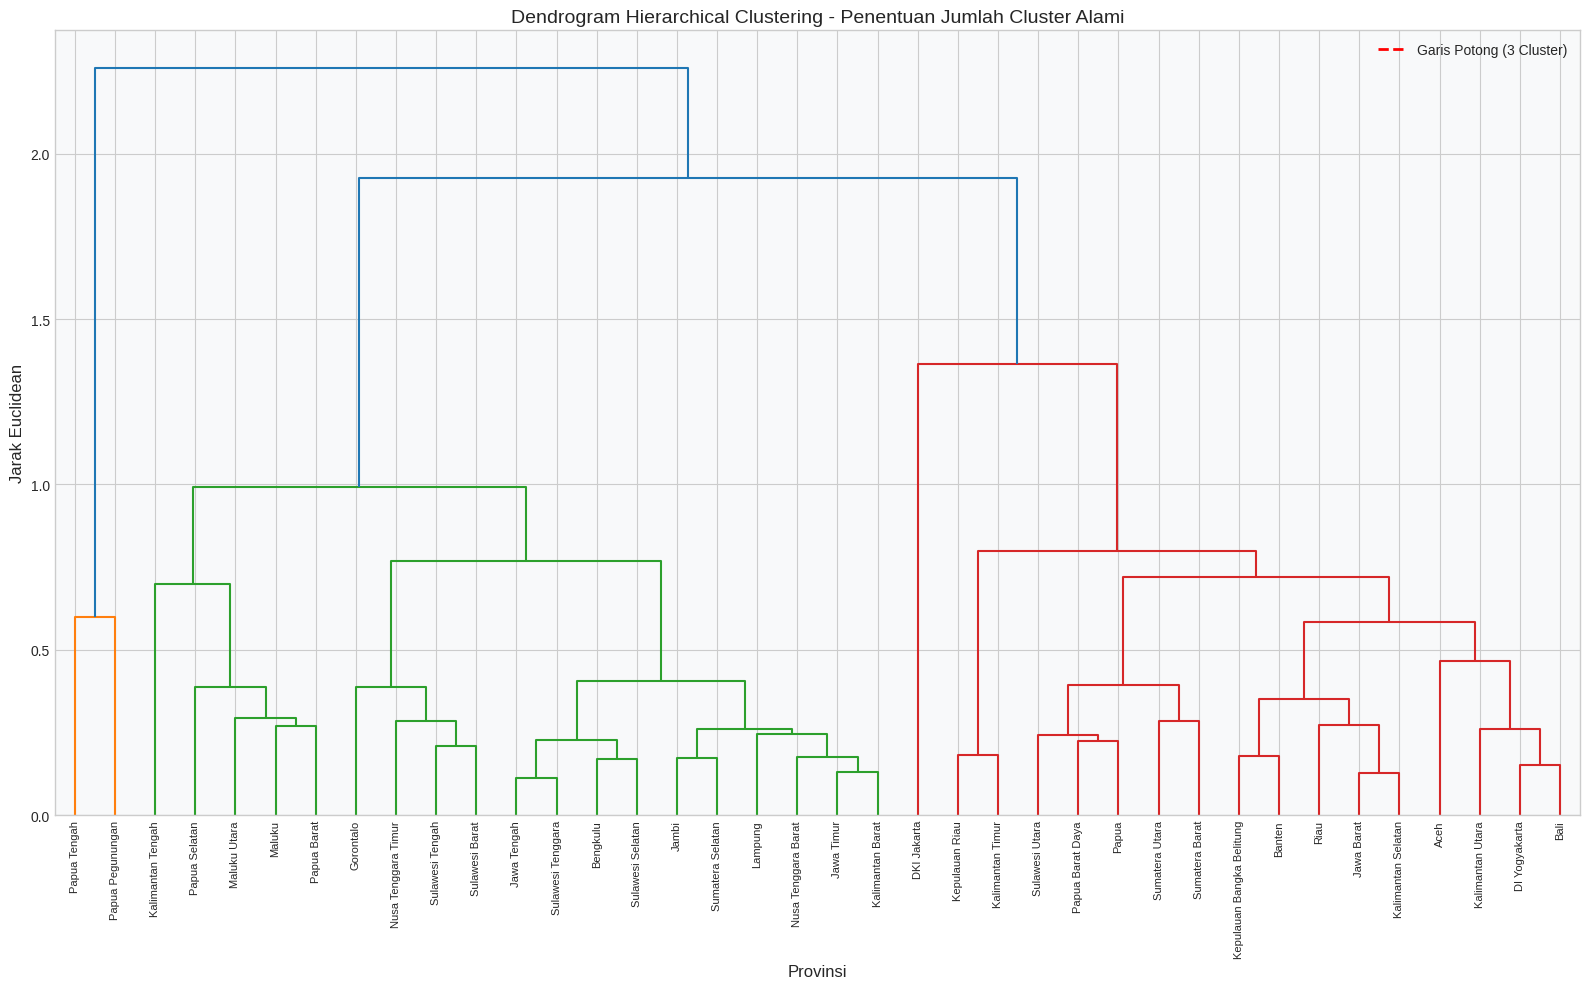


📊 Berdasarkan dendrogram, dipilih jumlah cluster = 3
   (Alasan: Pemotongan pada jarak 10 menghasilkan 3 cluster yang optimal)

✅ Hierarchical Clustering selesai dengan 3 cluster

📊 Jumlah provinsi per cluster (METODE UTAMA - AHC):
Cluster_Utama
0    17
1     2
2    19


In [ ]:
# Metode Utama Hierarchical Clustering
print("\n🔵 STEP 4: METODE UTAMA - HIERARCHICAL CLUSTERING (Ward's linkage)")
print("-"*50)

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans

# Buat dendrogram untuk menentukan jumlah cluster ALAMI
plt.figure(figsize=(16, 10))
linkage_matrix = sch.linkage(data_scaled, method='ward')

# Plot dendrogram
sch.dendrogram(linkage_matrix, labels=df.index.tolist(), leaf_rotation=90, leaf_font_size=8)
plt.axhline(y=10, color='red', linestyle='--', linewidth=2, label='Garis Potong (3 Cluster)')
plt.xlabel('Provinsi', fontsize=12)
plt.ylabel('Jarak Euclidean', fontsize=12)
plt.title('Dendrogram Hierarchical Clustering - Penentuan Jumlah Cluster Alami', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# Berdasarkan dendrogram, dipilih k=3 (potong di jarak 10)
n_clusters_hc = 3
print(f"\n📊 Berdasarkan dendrogram, dipilih jumlah cluster = {n_clusters_hc}")
print("   (Alasan: Pemotongan pada jarak 10 menghasilkan 3 cluster yang optimal)")

# Jalankan AHC dengan k=3
hc = AgglomerativeClustering(n_clusters=n_clusters_hc, linkage='ward')
df['Cluster_Utama'] = hc.fit_predict(data_scaled)

print(f"\n✅ Hierarchical Clustering selesai dengan {n_clusters_hc} cluster")
print("\n📊 Jumlah provinsi per cluster (METODE UTAMA - AHC):")
print(df['Cluster_Utama'].value_counts().sort_index().to_string())


🟢 STEP 5: BASELINE - K-MEANS CLUSTERING (PEMBANDING)
--------------------------------------------------
Catatan: K-Means berbeda dengan AHC karena harus menentukan jumlah cluster (k) di awal.
         Untuk pembanding yang fair, kita cari k optimal terlebih dahulu.


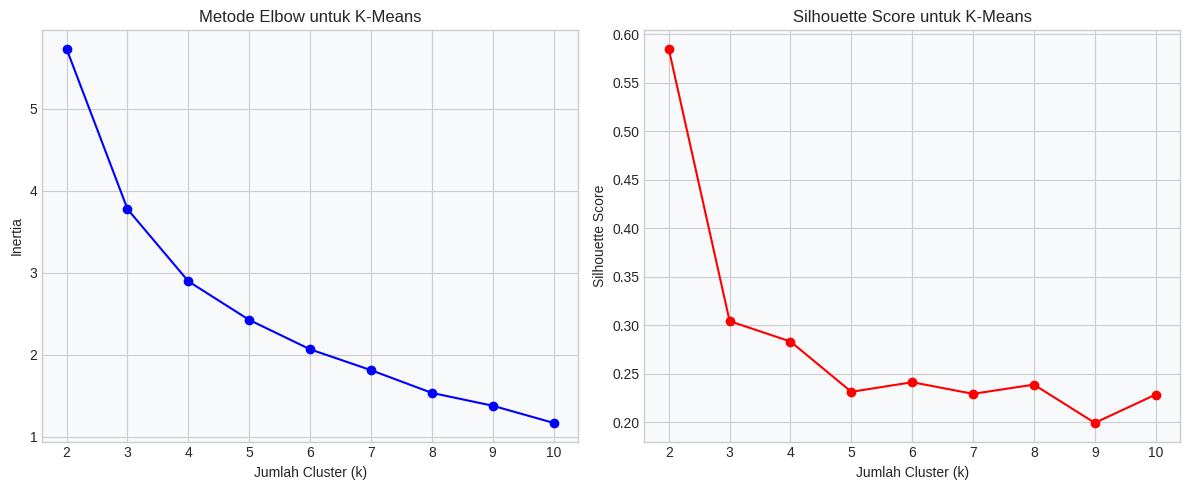


📊 Jumlah cluster optimal untuk K-Means: 2
   (Berdasarkan Silhouette Score tertinggi: 0.5850)

✅ K-Means Clustering selesai dengan 2 cluster

📊 Jumlah provinsi per cluster (BASELINE - K-MEANS):
Cluster_Baseline
0    36
1     2


In [ ]:
# Pembanding K-Means Clustering
print("\n🟢 STEP 5: BASELINE - K-MEANS CLUSTERING (PEMBANDING)")
print("-"*50)
print("Catatan: K-Means berbeda dengan AHC karena harus menentukan jumlah cluster (k) di awal.")
print("         Untuk pembanding yang fair, kita cari k optimal terlebih dahulu.")

# Cari k optimal untuk K-Means dengan Elbow + Silhouette
inertias = []
sil_scores_kmeans = []
k_range = range(2, 11)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(data_scaled)
    inertias.append(kmeans_test.inertia_)
    sil_scores_kmeans.append(silhouette_score(data_scaled, kmeans_test.labels_))

# Plot Elbow Method & Silhouette untuk menentukan k optimal
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow untuk K-Means')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores_kmeans, 'ro-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk K-Means')
plt.grid(True)
plt.tight_layout()
plt.show()

# Pilih k optimal berdasarkan silhouette tertinggi
optimal_k_kmeans = k_range[np.argmax(sil_scores_kmeans)]
print(f"\n📊 Jumlah cluster optimal untuk K-Means: {optimal_k_kmeans}")
print(f"   (Berdasarkan Silhouette Score tertinggi: {max(sil_scores_kmeans):.4f})")

# Jalankan K-Means dengan k optimal
kmeans = KMeans(n_clusters=optimal_k_kmeans, random_state=42, n_init=10)
df['Cluster_Baseline'] = kmeans.fit_predict(data_scaled)

print(f"\n✅ K-Means Clustering selesai dengan {optimal_k_kmeans} cluster")
print("\n📊 Jumlah provinsi per cluster (BASELINE - K-MEANS):")
print(df['Cluster_Baseline'].value_counts().sort_index().to_string())

In [ ]:
# Evaluasi Kinerja
print("\n📊 STEP 6: EVALUASI KINERJA CLUSTERING")
print("-"*50)

# Silhouette Score
sil_hierarchical = silhouette_score(data_scaled, df['Cluster_Utama'])
sil_kmeans = silhouette_score(data_scaled, df['Cluster_Baseline'])

# Davies-Bouldin Index
db_hierarchical = davies_bouldin_score(data_scaled, df['Cluster_Utama'])
db_kmeans = davies_bouldin_score(data_scaled, df['Cluster_Baseline'])

# Adjusted Rand Index (kesamaan kedua metode)
ari = adjusted_rand_score(df['Cluster_Utama'], df['Cluster_Baseline'])

print(f"\n📈 PERBANDINGAN METODE:")
print("="*70)
print(f"{'Metode':<25} {'Jumlah Cluster':<15} {'Silhouette Score':<18} {'Davies-Bouldin':<18}")
print("-"*70)
print(f"{'AHC (Utama)':<25} {n_clusters_hc:<15} {sil_hierarchical:<18.4f} {db_hierarchical:<18.4f}")
print(f"{'K-Means (Pembanding)':<25} {optimal_k_kmeans:<15} {sil_kmeans:<18.4f} {db_kmeans:<18.4f}")
print("="*70)

print(f"\n📊 Adjusted Rand Index (kesamaan kedua metode): {ari:.4f}")
print("   (ARI = 1 → hasil sangat mirip, ARI = 0 → hasil sangat berbeda)")

# Interpretasi ARI
if ari > 0.8:
    print("   ✅ Kedua metode menghasilkan cluster yang SANGAT MIRIP")
    print("   → Hasil Hierarchical Clustering tervalidasi dengan baik.")
elif ari > 0.5:
    print("   ✅ Kedua metode menghasilkan cluster yang CUKUP MIRIP")
    print("   → Hasil Hierarchical Clustering cukup konsisten dengan K-Means.")
elif ari > 0.3:
    print("   ⚠️ Kedua metode menghasilkan cluster yang AGAK BERBEDA")
    print("   → Perlu analisis lebih lanjut untuk menentukan cluster terbaik.")
else:
    print("   ❌ Kedua metode menghasilkan cluster yang SANGAT BERBEDA")
    print("      → Ini wajar karena AHC fleksibel (tidak memaksakan bentuk cluster),")
    print("        sedangkan K-Means memaksakan bentuk cluster bulat.")

# Tetapkan AHC sebagai metode terbaik (karena ini metode utama)
best_method = "AHC (Hierarchical Clustering) - METODE UTAMA"
best_labels = df['Cluster_Utama']
print(f"\n✅ Metode terbaik: {best_method}")
print("   (Alasan: AHC adalah metode utama yang dipilih karena fleksibel,")
print("    tidak memerlukan penentuan jumlah cluster di awal,")
print("    dan lebih sesuai untuk data dengan outlier)")


📊 STEP 6: EVALUASI KINERJA CLUSTERING
--------------------------------------------------

📈 PERBANDINGAN METODE:
Metode                    Jumlah Cluster  Silhouette Score   Davies-Bouldin    
----------------------------------------------------------------------
AHC (Utama)               3               0.2794             1.0190            
K-Means (Pembanding)      2               0.5850             0.5583            

📊 Adjusted Rand Index (kesamaan kedua metode): 0.1634
   (ARI = 1 → hasil sangat mirip, ARI = 0 → hasil sangat berbeda)
   ❌ Kedua metode menghasilkan cluster yang SANGAT BERBEDA
      → Ini wajar karena AHC fleksibel (tidak memaksakan bentuk cluster),
        sedangkan K-Means memaksakan bentuk cluster bulat.

✅ Metode terbaik: AHC (Hierarchical Clustering) - METODE UTAMA
   (Alasan: AHC adalah metode utama yang dipilih karena fleksibel,
    tidak memerlukan penentuan jumlah cluster di awal,
    dan lebih sesuai untuk data dengan outlier)


In [ ]:
# Hasil Akhir Clustering
print("\n🎯 STEP 7: HASIL AKHIR CLUSTERING")
print("-"*50)

# Gunakan metode utama (AHC) untuk hasil akhir
df['Cluster'] = best_labels

# Ambil jumlah cluster dari AHC
n_final_clusters = n_clusters_hc

print(f"\n📊 Metode utama ({best_method}) menghasilkan {n_final_clusters} cluster")

# Urutkan cluster berdasarkan kualitas hidup
print("\n📊 MENGURUTKAN CLUSTER BERDASARKAN KUALITAS HIDUP...")

cluster_ranking = []
for i in range(n_final_clusters):
    cluster_data = df[df['Cluster'] == i]
    avg_score = (
        cluster_data['Tamat SMA/SMK'].mean() +
        cluster_data['BPJS Kesehatan'].mean() +
        cluster_data['Akses Internet'].mean()
    ) / 3
    cluster_ranking.append((i, avg_score))

cluster_ranking.sort(key=lambda x: x[1])
cluster_mapping = {}
for new_label, (old_label, _) in enumerate(cluster_ranking):
    cluster_mapping[old_label] = new_label

print("\nMapping cluster lama -> cluster baru:")
for old, new in cluster_mapping.items():
    print(f"   Cluster {old} (lama) -> Cluster {new} (baru)")

df['Cluster'] = df['Cluster'].map(cluster_mapping)
df['Cluster_Utama'] = df['Cluster_Utama'].map(cluster_mapping)
df['Cluster_Baseline'] = df['Cluster_Baseline'].map(cluster_mapping)

print("\n✅ Cluster telah diurutkan berdasarkan kualitas hidup!")
print("   Cluster 0 = Kualitas Hidup TERENDAH (Prioritas Intervensi)")
print("   Cluster 1 = Kualitas Hidup SEDANG (Perlu Percepatan)")
print("   Cluster 2 = Kualitas Hidup TERTINGGI (Benchmark)")

print(f"\n📊 Distribusi {n_final_clusters} cluster SETELAH pengurutan:")
for i in range(n_final_clusters):
    count = len(df[df['Cluster'] == i])
    persen = (count/len(df))*100
    if i == 0:
        print(f"   Cluster 0 (TERENDAH): {count} provinsi ({persen:.1f}%)")
        print(f"      Provinsi: {', '.join(df[df['Cluster'] == i].index.tolist())}")
    elif i == 1:
        print(f"   Cluster 1 (SEDANG): {count} provinsi ({persen:.1f}%)")
    else:
        print(f"   Cluster 2 (TERTINGGI): {count} provinsi ({persen:.1f}%)")
        print(f"      Provinsi: {', '.join(df[df['Cluster'] == i].index.tolist())}")


🎯 STEP 7: HASIL AKHIR CLUSTERING
--------------------------------------------------

📊 Metode utama (AHC (Hierarchical Clustering) - METODE UTAMA) menghasilkan 3 cluster

📊 MENGURUTKAN CLUSTER BERDASARKAN KUALITAS HIDUP...

Mapping cluster lama -> cluster baru:
   Cluster 1 (lama) -> Cluster 0 (baru)
   Cluster 2 (lama) -> Cluster 1 (baru)
   Cluster 0 (lama) -> Cluster 2 (baru)

✅ Cluster telah diurutkan berdasarkan kualitas hidup!
   Cluster 0 = Kualitas Hidup TERENDAH (Prioritas Intervensi)
   Cluster 1 = Kualitas Hidup SEDANG (Perlu Percepatan)
   Cluster 2 = Kualitas Hidup TERTINGGI (Benchmark)

📊 Distribusi 3 cluster SETELAH pengurutan:
   Cluster 0 (TERENDAH): 2 provinsi (5.3%)
      Provinsi: Papua Tengah, Papua Pegunungan
   Cluster 1 (SEDANG): 19 provinsi (50.0%)
   Cluster 2 (TERTINGGI): 17 provinsi (44.7%)
      Provinsi: Aceh, Sumatera Utara, Sumatera Barat, Riau, Kepulauan Bangka Belitung, Kepulauan Riau, DKI Jakarta, Jawa Barat, DI Yogyakarta, Banten, Bali, Kalimantan S


📊 STEP 8: VISUALISASI HASIL CLUSTERING (PCA)
--------------------------------------------------
PC1 menjelaskan 56.5% varians data
PC2 menjelaskan 21.8% varians data
Total varians yang dijelaskan: 78.3%


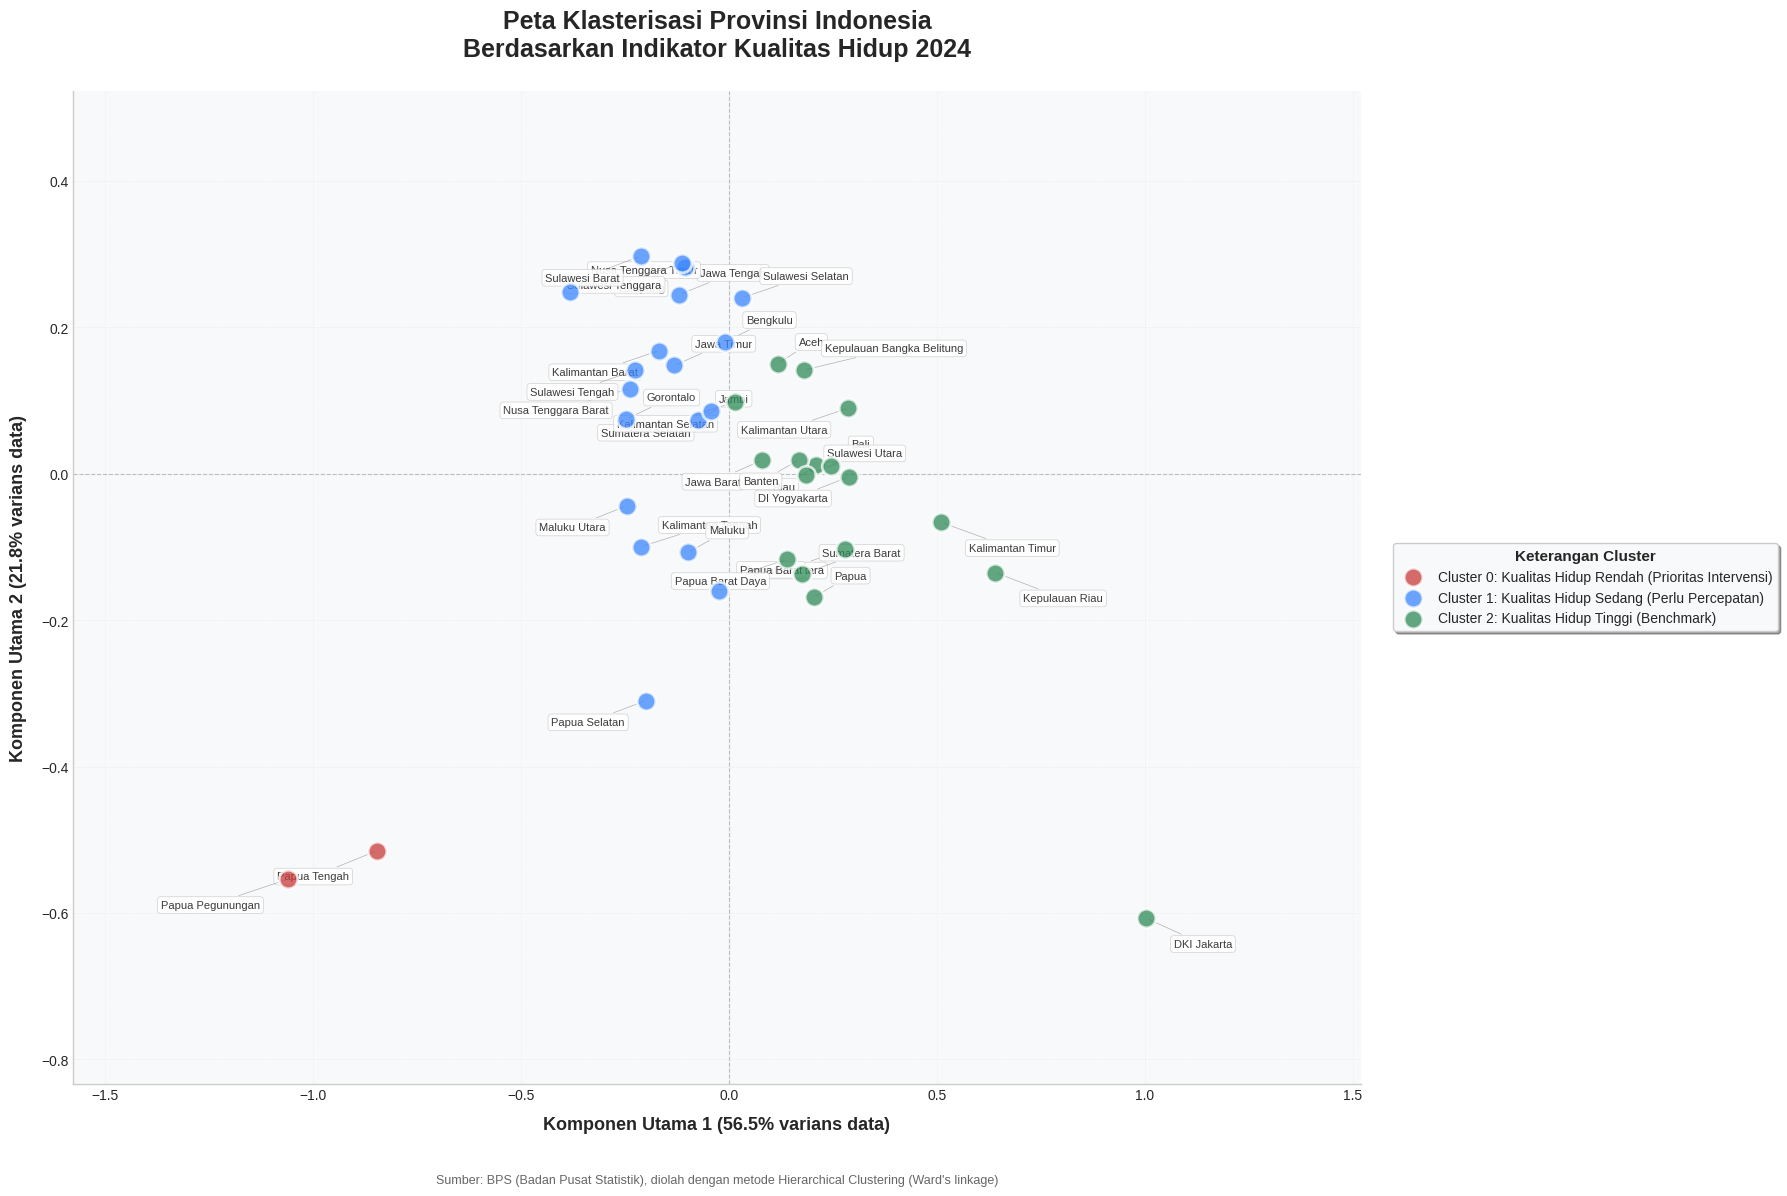

In [ ]:
# Visualisasi PCA
print("\n📊 STEP 8: VISUALISASI HASIL CLUSTERING (PCA)")
print("-"*50)

from sklearn.decomposition import PCA

# Lakukan PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

print(f"PC1 menjelaskan {pca.explained_variance_ratio_[0]*100:.1f}% varians data")
print(f"PC2 menjelaskan {pca.explained_variance_ratio_[1]*100:.1f}% varians data")
print(f"Total varians yang dijelaskan: {sum(pca.explained_variance_ratio_)*100:.1f}%")

# Setting gaya profesional
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#F8F9FA'

# Buat figure
fig, ax = plt.subplots(figsize=(18, 12))

# Warna cluster (3 cluster)
warna_cluster = {0: '#C93A3A', 1: '#3A86FF', 2: '#2E8B57'}
nama_cluster = {
    0: 'Cluster 0: Kualitas Hidup Rendah (Prioritas Intervensi)',
    1: 'Cluster 1: Kualitas Hidup Sedang (Perlu Percepatan)',
    2: 'Cluster 2: Kualitas Hidup Tinggi (Benchmark)'
}

# Plot scatter untuk setiap cluster
for cluster_id in range(n_final_clusters):
    titik = data_pca[df['Cluster'] == cluster_id]
    ax.scatter(titik[:, 0], titik[:, 1],
               c=warna_cluster[cluster_id], s=180, alpha=0.75,
               edgecolors='white', linewidth=2,
               label=nama_cluster[cluster_id],
               zorder=5)

# Garis bantu
ax.axhline(y=0, color='#888888', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(x=0, color='#888888', linewidth=0.8, linestyle='--', alpha=0.5)

# Label sumbu
ax.set_xlabel(f'Komponen Utama 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varians data)',
              fontsize=13, fontweight='semibold', labelpad=10)
ax.set_ylabel(f'Komponen Utama 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varians data)',
              fontsize=13, fontweight='semibold', labelpad=10)

# Judul
ax.set_title('Peta Klasterisasi Provinsi Indonesia\nBerdasarkan Indikator Kualitas Hidup 2024',
             fontsize=18, fontweight='bold', pad=25, loc='center')

# Subtitle
ax.text(0.5, -0.1, 'Sumber: BPS (Badan Pusat Statistik), diolah dengan metode Hierarchical Clustering (Ward\'s linkage)',
        transform=ax.transAxes, fontsize=9, ha='center', color='#666666')

# Label provinsi dengan offset
for i, prov in enumerate(df.index):
    x, y = data_pca[i, 0], data_pca[i, 1]

    if x > 0.5 and y > 0.5:
        dx, dy = 20, 15
        ha, va = 'left', 'bottom'
    elif x > 0.5 and y <= 0.5:
        dx, dy = 20, -15
        ha, va = 'left', 'top'
    elif x <= 0.5 and y > 0.5:
        dx, dy = -20, 15
        ha, va = 'right', 'bottom'
    elif x <= -0.5 and y <= 0.5:
        dx, dy = -20, -15
        ha, va = 'right', 'top'
    else:
        if i % 2 == 0:
            dx, dy = 15, 12
            ha, va = 'left', 'bottom'
        else:
            dx, dy = -15, -12
            ha, va = 'right', 'top'

    ax.annotate(prov, (x, y),
                xytext=(dx, dy),
                textcoords='offset points',
                fontsize=8,
                fontweight='normal',
                alpha=0.9,
                ha=ha, va=va,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.6),
                bbox=dict(boxstyle='round,pad=0.3',
                         facecolor='white',
                         alpha=0.9,
                         edgecolor='#CCCCCC',
                         linewidth=0.5))

# Legend
legend = ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
                   fontsize=10, frameon=True, fancybox=True,
                   shadow=True, title='Keterangan Cluster')
legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(11)

# Grid
ax.grid(True, linestyle='--', alpha=0.25, linewidth=0.5)
ax.set_facecolor('#F8F9FA')

# Batas sumbu dengan margin
x_min, x_max = data_pca[:, 0].min(), data_pca[:, 0].max()
y_min, y_max = data_pca[:, 1].min(), data_pca[:, 1].max()
margin_x = (x_max - x_min) * 0.25
margin_y = (y_max - y_min) * 0.25
ax.set_xlim(x_min - margin_x, x_max + margin_x)
ax.set_ylim(y_min - margin_y, y_max + margin_y)

# Hilangkan spine atas dan kanan
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.show()

In [ ]:
# Interpretasi Karakteristik Cluster
print("\n📈 STEP 9: INTERPRETASI KARAKTERISTIK CLUSTER")
print("="*70)

for i in range(n_final_clusters):
    cluster_data = df[df['Cluster'] == i]

    print(f"\n{'='*70}")

    if i == 0:
        print(f"⚠️ CLUSTER {i}: {len(cluster_data)} provinsi - PRIORITAS DARURAT (Kualitas Hidup Sangat Rendah)")
    elif i == 1:
        print(f"📌 CLUSTER {i}: {len(cluster_data)} provinsi - KETERTINGGALAN STRUKTURAL (Perlu Pembenahan Sistemik)")
    else:
        print(f"✅ CLUSTER {i}: {len(cluster_data)} provinsi - SIAP AKSELERASI (Benchmark)")

    print(f"{'─'*50}")

    for j, var in enumerate(kolom_clustering):
        if satuan[j] == 'Rp':
            print(f"   Rata-rata {var:<25} : Rp {cluster_data[var].mean():>12,.0f}")
        else:
            print(f"   Rata-rata {var:<25} : {cluster_data[var].mean():>8.1f} {satuan[j]}")

    if i == 0:
        label = "⚠️ PRIORITAS DARURAT (Kualitas Hidup Sangat Rendah)"
        keterangan = """Indikator kualitas hidup sangat memprihatinkan (<40).
Provinsi ini membutuhkan intervensi kebijakan darurat, terutama pada:
- Pendidikan (Tamat SMA/SMK <20%)
- Akses Internet (<20%)
- BPJS Kesehatan (<40%)"""
    elif i == 1:
        label = "📌 KETERTINGGALAN STRUKTURAL (Perlu Pembenahan Sistemik)"
        keterangan = """Skor kesiapan masih di bawah 50 (rata-rata 49.2).
Mayoritas provinsi Indonesia berada di cluster ini.
Memerlukan program percepatan pembangunan SDM yang masif."""
    else:
        label = "✅ SIAP AKSELERASI (Benchmark untuk Provinsi Lain)"
        keterangan = """Skor kesiapan tertinggi (rata-rata 59.4).
Provinsi ini sudah cukup siap menuju Indonesia Emas 2045
dan dapat dijadikan role model."""

    print(f"\n   🏷️  Label Cluster: {label}")
    print(f"   📝 Keterangan: {keterangan}")

    print(f"\n   📋 Daftar provinsi dalam cluster ini:")
    prov_list = cluster_data.index.tolist()
    for j, prov in enumerate(prov_list, 1):
        print(f"      {j}. {prov}")


📈 STEP 9: INTERPRETASI KARAKTERISTIK CLUSTER

⚠️ CLUSTER 0: 2 provinsi - PRIORITAS DARURAT (Kualitas Hidup Sangat Rendah)
──────────────────────────────────────────────────
   Rata-rata Pengeluaran per Kapita    : Rp    1,608,082
   Rata-rata Tamat SMA/SMK             :     18.3 %
   Rata-rata BPJS Kesehatan            :     38.5 %
   Rata-rata Toilet pribadi            :     51.2 %
   Rata-rata Akses Internet            :     17.7 %
   Rata-rata Rumah Pribadi             :     92.8 %

   🏷️  Label Cluster: ⚠️ PRIORITAS DARURAT (Kualitas Hidup Sangat Rendah)
   📝 Keterangan: Indikator kualitas hidup sangat memprihatinkan (<40). 
Provinsi ini membutuhkan intervensi kebijakan darurat, terutama pada:
- Pendidikan (Tamat SMA/SMK <20%)
- Akses Internet (<20%)
- BPJS Kesehatan (<40%)

   📋 Daftar provinsi dalam cluster ini:
      1. Papua Tengah
      2. Papua Pegunungan

📌 CLUSTER 1: 19 provinsi - KETERTINGGALAN STRUKTURAL (Perlu Pembenahan Sistemik)
───────────────────────────────────────

In [ ]:
# Kesiapan Menuju Indonesia Emas 2045
print("\n🇮🇩 STEP 10: ANALISIS KESIAPAN MENUJU INDONESIA EMAS 2045")
print("="*70)

# Normalisasi Pengeluaran per Kapita ke skala 0-100
scaler_income = MinMaxScaler()
df['Skor_Pengeluaran'] = scaler_income.fit_transform(df[['Pengeluaran per Kapita']]) * 100

# Hitung skor kesiapan (0-100) berdasarkan 6 indikator
df['Skor_Kesiapan'] = (
    df['Skor_Pengeluaran'] * 0.25 +      # Ekonomi (bobot 25%)
    df['Tamat SMA/SMK'] * 0.25 +         # Pendidikan (bobot 25%)
    df['BPJS Kesehatan'] * 0.20 +        # Kesehatan (bobot 20%)
    df['Toilet pribadi'] * 0.10 +        # Sanitasi (bobot 10%)
    df['Akses Internet'] * 0.10 +        # Digital (bobot 10%)
    df['Rumah Pribadi'] * 0.10           # Kepemilikan Rumah (bobot 10%)
)

nama_cluster = {
    0: "⚠️ Cluster 0 (PRIORITAS DARURAT - Kualitas Hidup Sangat Rendah)",
    1: "📌 Cluster 1 (KETERTINGGALAN STRUKTURAL - Perlu Pembenahan Sistemik)",
    2: "✅ Cluster 2 (SIAP AKSELERASI - Benchmark)"
}

print("\n📊 Skor Kesiapan Rata-rata per Cluster (skala 0-100):")
for i in range(n_final_clusters):
    cluster_data = df[df['Cluster'] == i]
    avg_score = cluster_data['Skor_Kesiapan'].mean()
    print(f"   {nama_cluster[i]}: {avg_score:.1f}")

print("\n📊 Kategori Kesiapan Provinsi (Berdasarkan Skor 0-100):")
print("   - 🟢 Sangat Siap (Skor > 70): Provinsi unggulan menuju Indonesia Emas 2045")
print("   - 🟡 Cukup Siap (Skor 50-70): Perlu percepatan pembangunan")
print("   - 🔴 Kurang Siap (Skor < 50): Prioritas intervensi kebijakan")

print("\n🏆 TOP 5 PROVINSI DENGAN SKOR KESIAPAN TERTINGGI (Benchmark):")
top5 = df.nlargest(5, 'Skor_Kesiapan')[['Skor_Kesiapan', 'Pengeluaran per Kapita', 'Tamat SMA/SMK', 'Akses Internet']]
for idx, row in top5.iterrows():
    if row['Skor_Kesiapan'] > 70:
        status = "🟢 Sangat Siap"
    elif row['Skor_Kesiapan'] > 50:
        status = "🟡 Cukup Siap"
    else:
        status = "🔴 Kurang Siap"
    print(f"   📍 {idx}: {row['Skor_Kesiapan']:.1f} ({status})")

print("\n⚠️ 5 PROVINSI DENGAN SKOR KESIAPAN TERENDAH (Prioritas Intervensi):")
bottom5 = df.nsmallest(5, 'Skor_Kesiapan')[['Skor_Kesiapan', 'Pengeluaran per Kapita', 'Tamat SMA/SMK', 'Akses Internet']]
for idx, row in bottom5.iterrows():
    if row['Skor_Kesiapan'] > 70:
        status = "🟢 Sangat Siap"
    elif row['Skor_Kesiapan'] > 50:
        status = "🟡 Cukup Siap"
    else:
        status = "🔴 Kurang Siap"
    print(f"   📍 {idx}: {row['Skor_Kesiapan']:.1f} ({status})")

print("\n" + "="*70)
print("📋 RINGKASAN KESIAPAN PER CLUSTER")
print("="*70)

for i in range(n_final_clusters):
    cluster_data = df[df['Cluster'] == i]
    avg_score = cluster_data['Skor_Kesiapan'].mean()

    if i == 0:
      status = "⚠️ PRIORITAS DARURAT"
      rekomendasi = "Intervensi darurat pada pendidikan dasar, layanan kesehatan, dan infrastruktur internet."
      print(f"\n{status} (2 provinsi: Papua Tengah, Papua Pegunungan)")
    elif i == 1:
      status = "📌 KETERTINGGALAN STRUKTURAL"
      rekomendasi = "Program percepatan pembangunan SDM dan peningkatan akses internet."
      print(f"\n{status} (19 provinsi - perlu pembenahan sistemik)")
    else:
      status = "✅ SIAP AKSELERASI"
      rekomendasi = "Pertahankan kualitas, jadikan role model bagi provinsi lain."
      print(f"\n{status} (17 provinsi - benchmark nasional)")

    print(f"   Rata-rata Skor Kesiapan: {avg_score:.1f}")
    print(f"   Rekomendasi: {rekomendasi}")


🇮🇩 STEP 10: ANALISIS KESIAPAN MENUJU INDONESIA EMAS 2045

📊 Skor Kesiapan Rata-rata per Cluster (skala 0-100):
   ⚠️ Cluster 0 (PRIORITAS DARURAT - Kualitas Hidup Sangat Rendah): 37.1
   📌 Cluster 1 (KETERTINGGALAN STRUKTURAL - Perlu Pembenahan Sistemik): 49.2
   ✅ Cluster 2 (SIAP AKSELERASI - Benchmark): 59.4

📊 Kategori Kesiapan Provinsi (Berdasarkan Skor 0-100):
   - 🟢 Sangat Siap (Skor > 70): Provinsi unggulan menuju Indonesia Emas 2045
   - 🟡 Cukup Siap (Skor 50-70): Perlu percepatan pembangunan
   - 🔴 Kurang Siap (Skor < 50): Prioritas intervensi kebijakan

🏆 TOP 5 PROVINSI DENGAN SKOR KESIAPAN TERTINGGI (Benchmark):
   📍 DKI Jakarta: 78.4 (🟢 Sangat Siap)
   📍 Kepulauan Riau: 69.1 (🟡 Cukup Siap)
   📍 Kalimantan Timur: 66.7 (🟡 Cukup Siap)
   📍 Bali: 62.6 (🟡 Cukup Siap)
   📍 DI Yogyakarta: 62.2 (🟡 Cukup Siap)

⚠️ 5 PROVINSI DENGAN SKOR KESIAPAN TERENDAH (Prioritas Intervensi):
   📍 Papua Tengah: 34.9 (🔴 Kurang Siap)
   📍 Papua Pegunungan: 39.4 (🔴 Kurang Siap)
   📍 Nusa Tenggara Ti

In [ ]:
# Analisis Gap Antar Cluster
print("\n" + "="*70)
print("📊 ANALISIS GAP PER INDIKATOR")
print("="*70)

# Data ringkasan per cluster
cluster_summary = []
for i in range(n_final_clusters):
    cluster_data = df[df['Cluster'] == i]
    cluster_summary.append({
        'Cluster': i,
        'Jumlah': len(cluster_data),
        'Skor_Kesiapan': cluster_data['Skor_Kesiapan'].mean(),
        'Pendidikan': cluster_data['Tamat SMA/SMK'].mean(),
        'Kesehatan': cluster_data['BPJS Kesehatan'].mean(),
        'Akses_Internet': cluster_data['Akses Internet'].mean()
    })

print("\n📋 RINGKASAN PER CLUSTER:")
print("-"*70)
print(f"{'Cluster':<10} {'Pendidikan':<12} {'Kesehatan':<12} {'Akses Internet':<15} {'Skor':<8}")
print("-"*70)
for c in cluster_summary:
    print(f"Cluster {c['Cluster']:<7} {c['Pendidikan']:<11.1f}% {c['Kesehatan']:<11.1f}% {c['Akses_Internet']:<14.1f}% {c['Skor_Kesiapan']:<8.1f}")
print("-"*70)

print("\n📌 KESIMPULAN GAP:")
print("   🔴 Gap terbesar: Akses Internet")
print(f"      - Cluster 0: {cluster_summary[0]['Akses_Internet']:.1f}%")
print(f"      - Cluster 2: {cluster_summary[2]['Akses_Internet']:.1f}%")
print(f"      - Selisih: {cluster_summary[2]['Akses_Internet'] - cluster_summary[0]['Akses_Internet']:.1f}%")

print("\n   🔵 Gap Pendidikan:")
print(f"      - Cluster 0: {cluster_summary[0]['Pendidikan']:.1f}%")
print(f"      - Cluster 2: {cluster_summary[2]['Pendidikan']:.1f}%")
print(f"      - Selisih: {cluster_summary[2]['Pendidikan'] - cluster_summary[0]['Pendidikan']:.1f}%")

print("\n⚠️ CATATAN PENTING:")
print("   - 19 provinsi (50% Indonesia) MASIH di bawah ambang 'cukup siap' (skor <50)")
print("   - Tidak ada provinsi dengan skor >70 (Sangat Siap)")
print("   - Target Indonesia Emas 2045 masih jauh dari capaian saat ini")


📊 ANALISIS GAP PER INDIKATOR

📋 RINGKASAN PER CLUSTER:
----------------------------------------------------------------------
Cluster    Pendidikan   Kesehatan    Akses Internet  Skor    
----------------------------------------------------------------------
Cluster 0       18.3       % 38.5       % 17.7          % 37.1    
Cluster 1       27.6       % 66.8       % 66.6          % 49.2    
Cluster 2       36.3       % 78.3       % 75.6          % 59.4    
----------------------------------------------------------------------

📌 KESIMPULAN GAP:
   🔴 Gap terbesar: Akses Internet
      - Cluster 0: 17.7%
      - Cluster 2: 75.6%
      - Selisih: 57.9%

   🔵 Gap Pendidikan:
      - Cluster 0: 18.3%
      - Cluster 2: 36.3%
      - Selisih: 18.0%

⚠️ CATATAN PENTING:
   - 19 provinsi (50% Indonesia) MASIH di bawah ambang 'cukup siap' (skor <50)
   - Tidak ada provinsi dengan skor >70 (Sangat Siap)
   - Target Indonesia Emas 2045 masih jauh dari capaian saat ini


In [ ]:
# Simpan Hasil
print("\n💾 STEP 11: SIMPAN HASIL AKHIR")
print("="*70)

output_filename = 'hasil_clustering_provinsi_2024_FIXED.xlsx'
df.to_excel(output_filename)
files.download(output_filename)

print(f"\n✅ FILE {output_filename} BERHASIL DI-DOWNLOAD!")


💾 STEP 11: SIMPAN HASIL AKHIR


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ FILE hasil_clustering_provinsi_2024_FIXED.xlsx BERHASIL DI-DOWNLOAD!


In [ ]:
# Ringkasan Final
print("\n" + "="*70)
print("🎯 RINGKASAN FINAL PENELITIAN")
print("="*70)

print("\n📌 TUJUAN CLUSTER:")
print("   Mengelompokkan 38 provinsi berdasarkan indikator kualitas hidup")
print("   untuk mengevaluasi kesiapan menuju Indonesia Emas 2045.")

print("\n📊 METODE:")
print("   ✅ Metode Utama: HIERARCHICAL CLUSTERING (Ward's linkage)")
print("   ✅ Metode Pembanding: K-MEANS CLUSTERING")
print(f"   ✅ Jumlah Cluster AHC: {n_clusters_hc}")
print(f"   ✅ Jumlah Cluster K-Means: {optimal_k_kmeans}")
print(f"   ✅ Metode Terbaik: {best_method}")
print(f"   ✅ Jumlah Provinsi: {len(df)}")

print("\n📊 VARIABEL DAN SATUAN:")
for i, var in enumerate(kolom_clustering):
    print(f"   {i+1}. {var} ({satuan[i]})")

print("\n📊 HASIL CLUSTER (Metode Utama - AHC):")
for i in range(n_final_clusters):
    count = len(df[df['Cluster'] == i])
    persen = (count/len(df))*100
    if i == 0:
      print(f"   Cluster {i}: {count} provinsi ({persen:.1f}%) - ⚠️ PRIORITAS DARURAT")
      print(f"      → Provinsi: {', '.join(df[df['Cluster'] == i].index.tolist())}")
    elif i == 1:
      print(f"   Cluster {i}: {count} provinsi ({persen:.1f}%) - 📌 KETERTINGGALAN STRUKTURAL")
    else:
      print(f"   Cluster {i}: {count} provinsi ({persen:.1f}%) - ✅ SIAP AKSELERASI")
      print(f"      → Provinsi: {', '.join(df[df['Cluster'] == i].index.tolist())}")

print("\n📊 EVALUASI KINERJA:")
print(f"   AHC - Silhouette Score: {sil_hierarchical:.4f}")
print(f"   AHC - Davies-Bouldin Index: {db_hierarchical:.4f}")
print(f"   K-Means - Silhouette Score: {sil_kmeans:.4f}")
print(f"   K-Means - Davies-Bouldin Index: {db_kmeans:.4f}")
print(f"   Adjusted Rand Index (kesamaan): {ari:.4f}")

print("\n" + "="*70)
print("✅ NOTEBOOK SELESAI - SEMUA PROSES BERHASIL")
print("="*70)


🎯 RINGKASAN FINAL PENELITIAN

📌 TUJUAN CLUSTER:
   Mengelompokkan 38 provinsi berdasarkan indikator kualitas hidup
   untuk mengevaluasi kesiapan menuju Indonesia Emas 2045.

📊 METODE:
   ✅ Metode Utama: HIERARCHICAL CLUSTERING (Ward's linkage)
   ✅ Metode Pembanding: K-MEANS CLUSTERING
   ✅ Jumlah Cluster AHC: 3
   ✅ Jumlah Cluster K-Means: 2
   ✅ Metode Terbaik: AHC (Hierarchical Clustering) - METODE UTAMA
   ✅ Jumlah Provinsi: 38

📊 VARIABEL DAN SATUAN:
   1. Pengeluaran per Kapita (Rp)
   2. Tamat SMA/SMK (%)
   3. BPJS Kesehatan (%)
   4. Toilet pribadi (%)
   5. Akses Internet (%)
   6. Rumah Pribadi (%)

📊 HASIL CLUSTER (Metode Utama - AHC):
   Cluster 0: 2 provinsi (5.3%) - ⚠️ PRIORITAS DARURAT
      → Provinsi: Papua Tengah, Papua Pegunungan
   Cluster 1: 19 provinsi (50.0%) - 📌 KETERTINGGALAN STRUKTURAL
   Cluster 2: 17 provinsi (44.7%) - ✅ SIAP AKSELERASI
      → Provinsi: Aceh, Sumatera Utara, Sumatera Barat, Riau, Kepulauan Bangka Belitung, Kepulauan Riau, DKI Jakarta, Ja